## Géométrie de l'accouplement fourche–T : relation entre l'angle moteur et l'angle tige

Modèle : un point (ergot) est entraîné à rayon fixe $R$ autour de l'axe moteur $O_1$ (angle $\alpha$).
L'axe tige $O_2$, décalé radialement de $e$ par rapport à $O_1$, « regarde » ce même point :
son orientation $\beta$ est donc l'angle, vu depuis $O_2$, du point entraîné par le moteur.

$$\beta(\alpha) = \cos^{-1}\!\left(\frac{R\cos\alpha+e}{\sqrt{(R\cos\alpha+e)^2+(R\sin\alpha)^2}}\right)$$

Cette forme en $\cos^{-1}$ ne renvoie que des valeurs dans $[0°,180°]$. La forme équivalente avec
`atan2` gère cela nativement sur $[0°,360°[$ :

$$\beta(\alpha) = \operatorname{atan2}\big(R\sin\alpha,\ e+R\cos\alpha\big) \qquad \text{(valable pour } \alpha\in[0°,180°))$$

**Symétrie du système :** la fourche en T (tige) est symétrique (deux bras à 180°). Passé un
demi-tour moteur, c'est le second bras qui prend le relais du premier, reproduisant exactement
la même relation géométrique. Le modèle ci-dessus n'est donc valable que sur un demi-tour ;
il se prolonge par périodicité de 180° :

$$\beta(\alpha+180°) = \beta(\alpha) + 180°$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres (mm)
R = 12.5     # rayon d'entraînement (demi-écart de la fourche)
E = 3.18     # désalignement radial réel (Delta h, voir rapport)

BLUE = "#378ADD"
ORANGE = "#D85A30"

def beta_raw(alpha, e, R=R):
    """Relation de base, valable seulement pour alpha dans [0, 180 deg[ (un seul bras actif)."""
    return np.arctan2(R * np.sin(alpha), e + R * np.cos(alpha))

def beta_of_alpha(alpha, e, R=R):
    """Angle tige beta, prolonge par periodicite de 180 deg (symetrie de la fourche en T) :
    beta(alpha + pi) = beta(alpha) + pi."""
    n = np.floor(alpha / np.pi)
    return beta_raw(alpha - n * np.pi, e, R) + n * np.pi


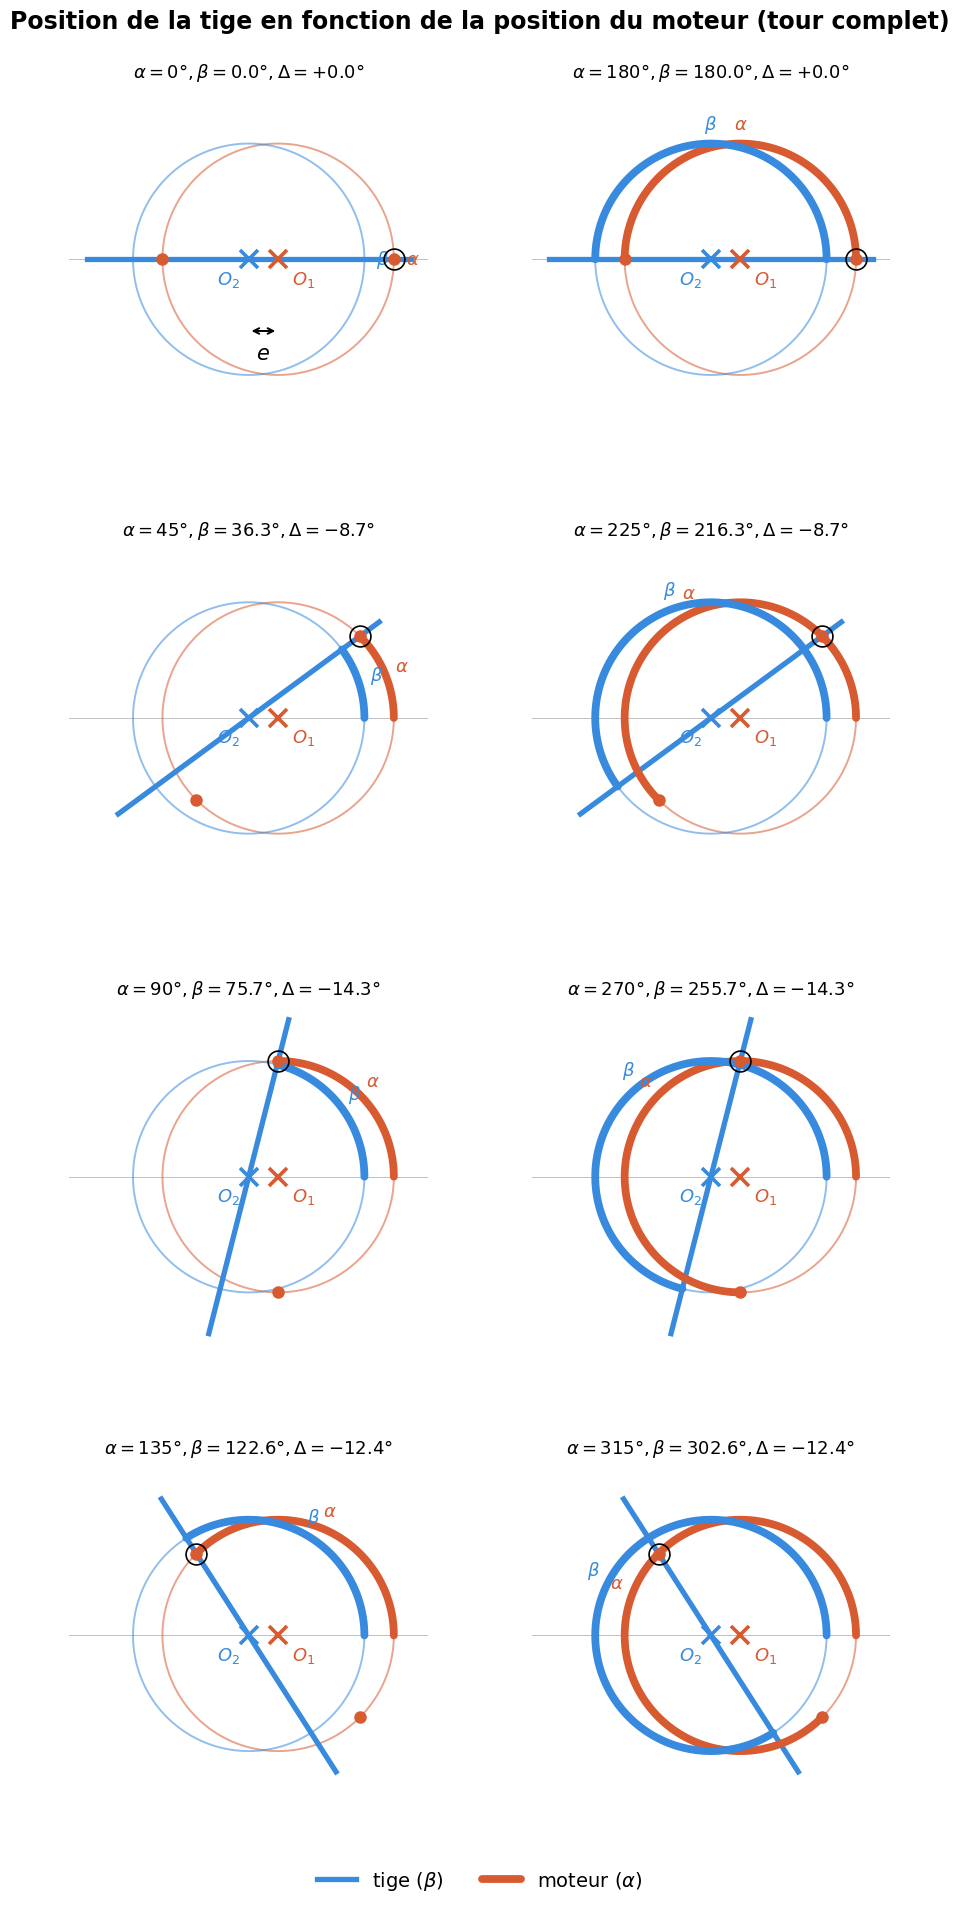

In [2]:
# Figure 1 : geometrie a differentes positions du moteur, tous les 45 deg sur un tour complet.
# Grille 4 lignes x 2 colonnes : colonne 1 = 0,45,90,135 deg ; colonne 2 = 180,225,270,315 deg.
# Les deux points ou le "bras" moteur croiserait le cercle moteur sont toujours marques (symetrie
# de la fourche en T) ; celui qui est effectivement actif (cf. beta_of_alpha) est entoure. On observe
# que la colonne 2 reproduit exactement les valeurs de Delta de la colonne 1, avec le point actif
# desormais en bas : c'est la periodicite de 180 deg.
angles_deg = [0, 45, 90, 135, 180, 225, 270, 315]
OVERSHOOT = 5.0  # mm, depassement du trait tige de chaque cote du cercle

fig, axes = plt.subplots(4, 2, figsize=(9.6, 19))

for idx, a_deg in enumerate(angles_deg):
    row, col = idx % 4, idx // 4   # remplissage colonne par colonne
    ax = axes[row, col]

    a = np.radians(a_deg)
    b = beta_of_alpha(a, E)
    b_deg = np.degrees(b)
    delta_deg = b_deg - a_deg
    active_bottom = a_deg >= 180  # bras actif : haut (< 180 deg) ou bas (>= 180 deg)

    O1 = np.array([E, 0.0])
    O2 = np.array([0.0, 0.0])
    dir_a = np.array([np.cos(a), np.sin(a)])
    dir_b = np.array([np.cos(b), np.sin(b)])

    P = O1 + R * dir_a                      # point sur le cercle moteur (orange), bras "haut"
    P_opp = O1 - R * dir_a                  # bras oppose (symetrique), "bas"
    Pb = O2 + (R + OVERSHOOT) * dir_b        # trait tige, depasse le cercle tige de OVERSHOOT
    Pb_opp = O2 - (R + OVERSHOOT) * dir_b
    P_active = P_opp if active_bottom else P

    th = np.linspace(0, 2*np.pi, 300)
    ax.plot(O1[0]+R*np.cos(th), O1[1]+R*np.sin(th), color=ORANGE, lw=1.4, alpha=0.55)
    ax.plot(O2[0]+R*np.cos(th), O2[1]+R*np.sin(th), color=BLUE, lw=1.4, alpha=0.55)

    ax.axhline(0, color="gray", lw=0.7, alpha=0.5)
    # trait pointille reliant le point actif (cercle moteur) au point correspondant (cercle tige)
    ax.plot([P_active[0], O2[0]+R*np.cos(b)], [P_active[1], O2[1]+R*np.sin(b)],
            color="gray", lw=1.4, ls=(0, (4, 3)))

    ax.plot([Pb_opp[0], Pb[0]], [Pb_opp[1], Pb[1]], color=BLUE, lw=3.8,
            label="tige ($\\beta$)" if idx == 0 else None)

    # angles alpha/beta : arc epaissi cumule directement sur le cercle (peut depasser 180 deg)
    th_a = np.linspace(0, a, max(int(80*a_deg/45), 2))
    th_b = np.linspace(0, b, max(int(80*abs(b_deg)/45), 2))
    ax.plot(O1[0]+R*np.cos(th_a), O1[1]+R*np.sin(th_a), color=ORANGE, lw=5.6, solid_capstyle="round",
            label="moteur ($\\alpha$)" if idx == 0 else None)
    ax.plot(O2[0]+R*np.cos(th_b), O2[1]+R*np.sin(th_b), color=BLUE, lw=5.6, solid_capstyle="round")

    lbl_r = 1.16 * R
    ax.text(O1[0]+lbl_r*np.cos(a/2), O1[1]+lbl_r*np.sin(a/2), r"$\alpha$",
            color=ORANGE, fontsize=13, ha="center", va="center")
    ax.text(O2[0]+lbl_r*np.cos(b/2), O2[1]+lbl_r*np.sin(b/2), r"$\beta$",
            color=BLUE, fontsize=13, ha="center", va="center")

    ax.plot(*O1, marker="x", color=ORANGE, ms=13, mew=2.6, zorder=5)
    ax.plot(*O2, marker="x", color=BLUE, ms=13, mew=2.6, zorder=5)
    ax.plot(*P, "o", color=ORANGE, ms=8, zorder=5)
    ax.plot(*P_opp, "o", color=ORANGE, ms=8, zorder=5)
    ax.plot(*P_active, "o", color="none", ms=15, mec="black", mew=1.2, zorder=6)  # entoure le bras actif

    ax.annotate("$O_1$", O1, textcoords="offset points", xytext=(10, -18), fontsize=13, color=ORANGE, fontweight="bold")
    ax.annotate("$O_2$", O2, textcoords="offset points", xytext=(-23, -18), fontsize=13, color=BLUE, fontweight="bold")

    if idx == 0:
        y_e = -0.62 * R
        ax.annotate("", xy=(O1[0], y_e), xytext=(O2[0], y_e),
                    arrowprops=dict(arrowstyle="<->", color="black", lw=1.4))
        ax.text((O1[0]+O2[0])/2, y_e-0.11*R, "$e$", ha="center", va="top", fontsize=15)

    ax.set_xlim(-1.55*R, 1.55*R)
    ax.set_ylim(-1.55*R, 1.5*R)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(f"$\\alpha={a_deg}\u00b0,\\beta={b_deg:.1f}\u00b0,\\Delta={delta_deg:+.1f}\u00b0$", fontsize=13, pad=6)

fig.legend(loc="lower center", ncol=2, fontsize=14, frameon=False, bbox_to_anchor=(0.5, -0.005))
fig.suptitle("Position de la tige en fonction de la position du moteur (tour complet)", fontsize=17, fontweight="bold", y=0.995)
fig.subplots_adjust(top=0.955, bottom=0.045, left=0.03, right=0.97, hspace=0.3, wspace=0.05)
fig.savefig("../../figures/Implementation/fig_positions_angle.png", dpi=130)
plt.show()


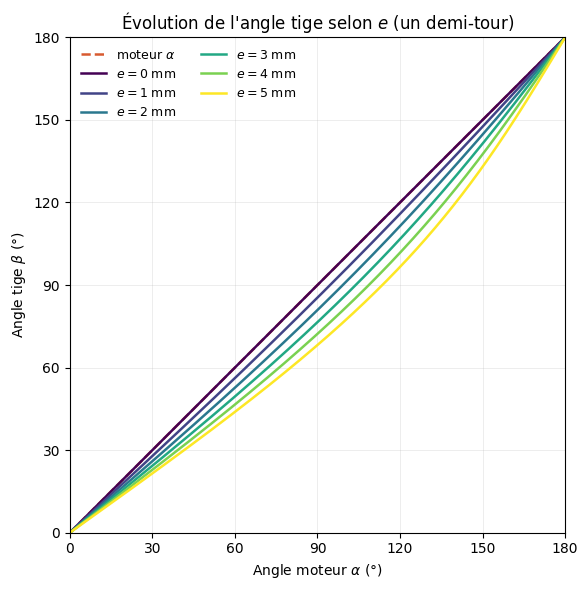

In [3]:
# Figure 2a : evolution de l'angle tige beta selon alpha, pour plusieurs valeurs de e (0 a 5 mm)
# Limite a [0,180 deg] : le systeme etant periodique de 180 deg (symetrie de la fourche en T),
# un demi-tour suffit a representer tout le comportement.
import matplotlib.cm as cm

e_values = [0, 1, 2, 3, 4, 5]
cmap = cm.get_cmap("viridis")
colors = [cmap(i/(len(e_values)-1)) for i in range(len(e_values))]

alpha = np.linspace(0, np.pi, 2000)
alpha_deg = np.degrees(alpha)

fig, ax1 = plt.subplots(figsize=(7, 6))

ax1.plot(alpha_deg, alpha_deg, color=ORANGE, lw=1.8, ls="--", label="moteur $\\alpha$")
for e, c in zip(e_values, colors):
    beta_deg = np.degrees(beta_raw(alpha, e))
    ax1.plot(alpha_deg, beta_deg, color=c, lw=1.8, label=f"$e={e}$ mm")

ax1.set_xlabel("Angle moteur $\\alpha$ (\u00b0)")
ax1.set_ylabel("Angle tige $\\beta$ (\u00b0)")
ax1.set_title("Évolution de l'angle tige selon $e$ (un demi-tour)")
ax1.set_xlim(0, 180); ax1.set_ylim(0, 180)
ax1.set_xticks(range(0, 181, 30)); ax1.set_yticks(range(0, 181, 30))
ax1.set_aspect("equal")
ax1.grid(True, lw=0.4, alpha=0.4)
ax1.legend(fontsize=9, frameon=False, ncol=2, loc="upper left")

fig.tight_layout()
fig.savefig("../../figures/Implementation/fig_beta_evolution.png", dpi=150)
plt.show()


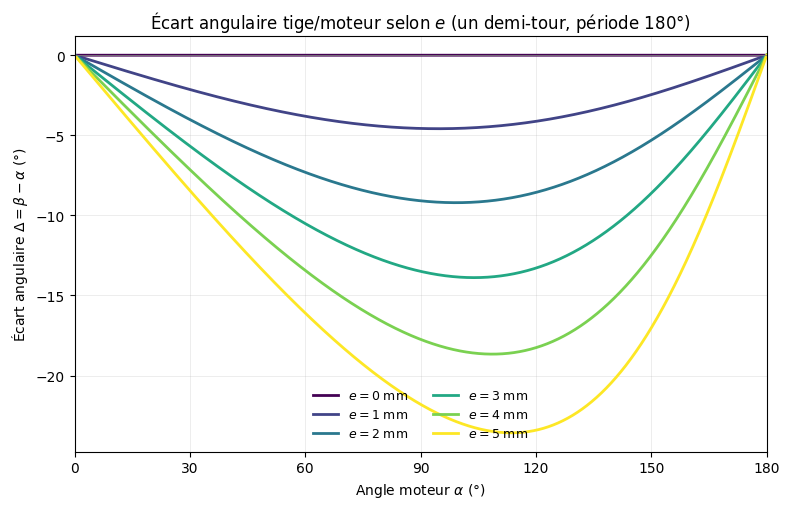

Delta_max(e=3.18mm) = 14.738 deg (atteint deux fois par tour)


In [4]:
# Figure 2b : ecart angulaire tige/moteur selon alpha, pour plusieurs valeurs de e (0 a 5 mm)
# Limite a [0,180 deg] (periode 180 deg, symetrie de la fourche en T) : le motif se repete a
# l'identique tous les demi-tours, un seul suffit a le representer.
fig, ax2 = plt.subplots(figsize=(8, 5.2))

for e, c in zip(e_values, colors):
    beta_deg = np.degrees(beta_raw(alpha, e))
    delta_deg = beta_deg - alpha_deg
    ax2.plot(alpha_deg, delta_deg, color=c, lw=2.0, label=f"$e={e}$ mm")

ax2.axhline(0, color="gray", lw=0.6)
ax2.set_xlabel("Angle moteur $\\alpha$ (\u00b0)")
ax2.set_ylabel("Écart angulaire $\\Delta=\\beta-\\alpha$ (\u00b0)")
ax2.set_title("Écart angulaire tige/moteur selon $e$ (un demi-tour, période 180°)")
ax2.set_xlim(0, 180)
ax2.set_xticks(range(0, 181, 30))
ax2.grid(True, lw=0.4, alpha=0.4)
ax2.legend(fontsize=9, frameon=False, ncol=2, loc="lower center")

fig.tight_layout()
fig.savefig("../../figures/Implementation/fig_delta_evolution.png", dpi=150)
plt.show()

print(f"Delta_max(e=3.18mm) = {np.degrees(np.arcsin(E/R)):.3f} deg (atteint deux fois par tour)")


e limite pour 15 min (Mvt01) = 7.796 mm


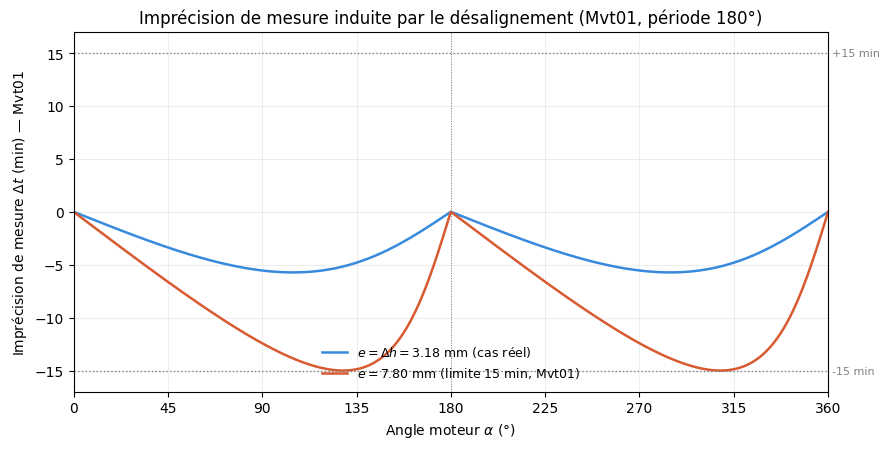

In [5]:
# Figure 3 : illustration de l'imprecision de mesure au desalignement limite (15 min, Mvt01)
# Utilise beta_of_alpha (corrige, periodique de 180 deg).
RM_mvt01, N_total_mvt01, r_mvt01 = 80, 10.30, 3.33
N_tige_mvt01 = r_mvt01 * N_total_mvt01
s_par_deg_mvt01 = 10 * RM_mvt01 / N_tige_mvt01     # secondes par degre d'ecart

E_15MIN = R * np.sin(np.radians(900 / s_par_deg_mvt01))  # e tel que Delta_max*s_par_deg = 900 s
print(f"e limite pour 15 min (Mvt01) = {E_15MIN:.3f} mm")

alpha = np.linspace(0, 2*np.pi, 4000)
alpha_deg = np.degrees(alpha)

fig, ax = plt.subplots(figsize=(9, 4.6))
for e, color, label in [(E, BLUE, f"$e=\\Delta h={E:.2f}$ mm (cas réel)"),
                         (E_15MIN, ORANGE, f"$e={E_15MIN:.2f}$ mm (limite 15 min, Mvt01)")]:
    beta_deg = np.degrees(beta_of_alpha(alpha, e))
    delta_deg = beta_deg - alpha_deg
    dt_min = delta_deg * s_par_deg_mvt01 / 60
    ax.plot(alpha_deg, dt_min, color=color, lw=1.8, label=label)

ax.axhline(15, color="gray", lw=1.0, ls=":")
ax.axhline(-15, color="gray", lw=1.0, ls=":")
ax.axvline(180, color="gray", lw=0.7, ls=":")
ax.text(362, 15, "+15 min", va="center", fontsize=8, color="gray")
ax.text(362, -15, "-15 min", va="center", fontsize=8, color="gray")
ax.set_xlabel("Angle moteur $\\alpha$ (\u00b0)")
ax.set_ylabel("Imprécision de mesure $\\Delta t$ (min) \u2014 Mvt01")
ax.set_title("Imprécision de mesure induite par le désalignement (Mvt01, période 180°)")
ax.set_xlim(0, 360)
ax.set_xticks(range(0, 361, 45))
ax.set_ylim(-17, 17)
ax.grid(True, lw=0.4, alpha=0.4)
ax.legend(fontsize=9, frameon=False, loc="lower center")
fig.tight_layout()
fig.savefig("../../figures/Implementation/fig_precision_e_limite.png", dpi=150)
plt.show()
